# Federated Learning vs Centralised Training — DDoS Detection
**Models:** Decision Tree · Random Forest · SVM (RBF) · Logistic Regression · Naive Bayes · CNN (1D)
**Dataset:** CIC-DDoS2019 (unified split)
**Reference baseline:** Ahmed et al. (2026) — Table 4 (CIC-DDoS2019 column)
**FL strategy:** Manual FedAvg / Federated Forest / Ensemble Voting (model-specific)
**Feature selection:** 5-method hybrid union → 49 features

## 1. Config Preparation

In [1]:
# Import Library
import warnings, time, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import MinMaxScaler, KBinsDiscretizer
from sklearn.feature_selection import (SelectKBest, chi2, f_classif,
                                       mutual_info_classif)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.inspection import permutation_importance

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
# Path
BASE     = r"d:\DATA ENGINEERING\Federated Learning"
TRAIN_CSV = os.path.join(BASE, "ddos-dataset-processing", "unified_train.csv")
VAL_CSV   = os.path.join(BASE, "ddos-dataset-processing", "unified_val.csv")
TEST_CSV  = os.path.join(BASE, "ddos-dataset-processing", "unified_test.csv")

# Federated Learning Config
FL_ROUNDS    = 10
LOCAL_EPOCHS = 5 # CNN
N_CLIENTS    = 2

# Reference paper results
PAPER = {
    "Decision Tree":       {"accuracy":0.957,"precision":0.944,"recall":0.951,"f1":0.947},
    "Random Forest":       {"accuracy":0.978,"precision":0.969,"recall":0.971,"f1":0.970},
    "SVM (RBF)":           {"accuracy":0.972,"precision":0.961,"recall":0.964,"f1":0.962},
    "Logistic Regression": {"accuracy":0.965,"precision":0.952,"recall":0.956,"f1":0.954},
    "Naive Bayes":         {"accuracy":0.931,"precision":0.909,"recall":0.917,"f1":0.913},
    "CNN (1D)":            {"accuracy":0.981,"precision":0.974,"recall":0.976,"f1":0.975},
}

MODEL_ORDER = list(PAPER.keys())
METRICS     = ["accuracy", "precision", "recall", "f1"]

## 1. ABOUT DATASET with EDA

Train+Val: (362164, 78)  |  Test: (63912, 78)
Label distribution (train+val):
Label
1    281666
0     80498
Name: count, dtype: int64

Label distribution (test):
Label
1    49706
0    14206
Name: count, dtype: int64


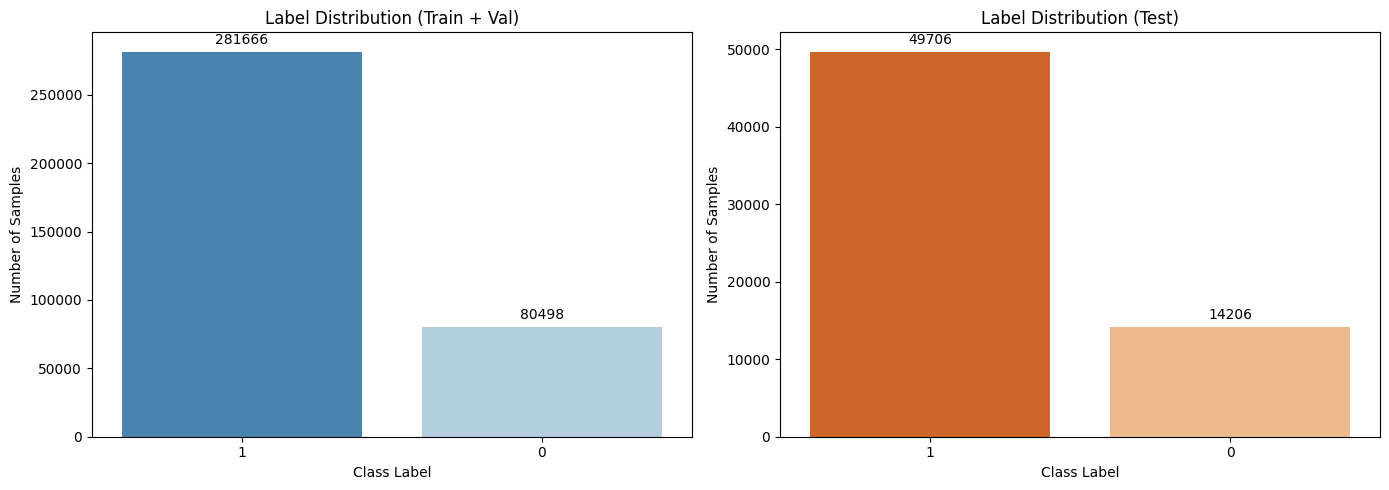

In [3]:
# Merge train + val → full training set (85 %)
df_train_raw = pd.concat([pd.read_csv(TRAIN_CSV), pd.read_csv(VAL_CSV)], ignore_index=True)
df_test_raw  = pd.read_csv(TEST_CSV)

print(f"Train+Val: {df_train_raw.shape}  |  Test: {df_test_raw.shape}")

print("Label distribution (train+val):")
print(df_train_raw["Label"].value_counts())

print("\nLabel distribution (test):")
print(df_test_raw["Label"].value_counts())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=df_train_raw, 
    x="Label", 
    ax=axes[0], 
    palette="Blues_r",
    order=df_train_raw["Label"].value_counts().index # Sorts bars by frequency
)
axes[0].set_title("Label Distribution (Train + Val)")
axes[0].set_xlabel("Class Label")
axes[0].set_ylabel("Number of Samples")

for container in axes[0].containers:
    axes[0].bar_label(container, padding=3)

sns.countplot(
    data=df_test_raw, 
    x="Label", 
    ax=axes[1], 
    palette="Oranges_r",
    order=df_test_raw["Label"].value_counts().index
)
axes[1].set_title("Label Distribution (Test)")
axes[1].set_xlabel("Class Label")
axes[1].set_ylabel("Number of Samples")

for container in axes[1].containers:
    axes[1].bar_label(container, padding=3)

plt.tight_layout()
plt.show()

In [5]:
# Dataset overview — shape, nulls, dtypes, class balance
print("=== DATASET OVERVIEW ===")
print(f"Train+Val : {df_train_raw.shape[0]:,} rows x {df_train_raw.shape[1]} columns")
print(f"Test      : {df_test_raw.shape[0]:,} rows x {df_test_raw.shape[1]} columns")
print(f"\nNull values  — Train+Val : {df_train_raw.isnull().sum().sum()}")
print(f"Null values  — Test      : {df_test_raw.isnull().sum().sum()}")
print(f"\nColumn dtypes:\n{df_train_raw.dtypes.value_counts().to_string()}")
print(f"\nClass balance (Train+Val):")
for lbl, cnt in df_train_raw['Label'].value_counts().items():
    name = 'Benign' if lbl == 0 else 'DDoS'
    print(f"  Class {lbl} ({name}): {cnt:,} samples ({cnt/len(df_train_raw)*100:.1f}%)")

=== DATASET OVERVIEW ===
Train+Val : 362,164 rows x 78 columns
Test      : 63,912 rows x 78 columns

Null values  — Train+Val : 0
Null values  — Test      : 0

Column dtypes:
float64    77
int64       1

Class balance (Train+Val):
  Class 1 (DDoS): 281,666 samples (77.8%)
  Class 0 (Benign): 80,498 samples (22.2%)


### Feature Correlation

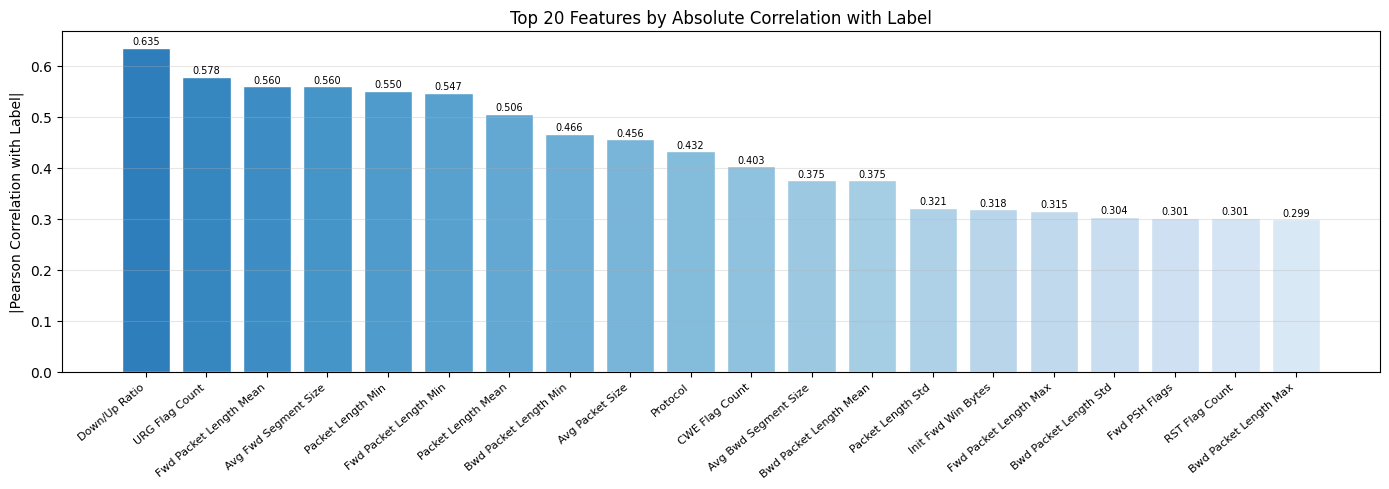

In [6]:
# Pearson correlation of every numeric feature with the binary Label column
numeric_train = df_train_raw.select_dtypes(include=[np.number])
corr_target   = numeric_train.corr()['Label'].drop('Label')
corr_abs      = corr_target.abs().sort_values(ascending=False)
top20_names   = corr_abs.head(20).index.tolist()

fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = plt.cm.Blues_r(np.linspace(0.3, 0.85, 20))
bars = ax.bar(range(20), corr_abs.head(20).values, color=bar_colors, edgecolor='white')
ax.set_xticks(range(20))
ax.set_xticklabels(top20_names, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('|Pearson Correlation with Label|')
ax.set_title('Top 20 Features by Absolute Correlation with Label', fontsize=12)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, corr_abs.head(20).values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.show()

### Correlation Heatmap (Top 20 Features + Label)

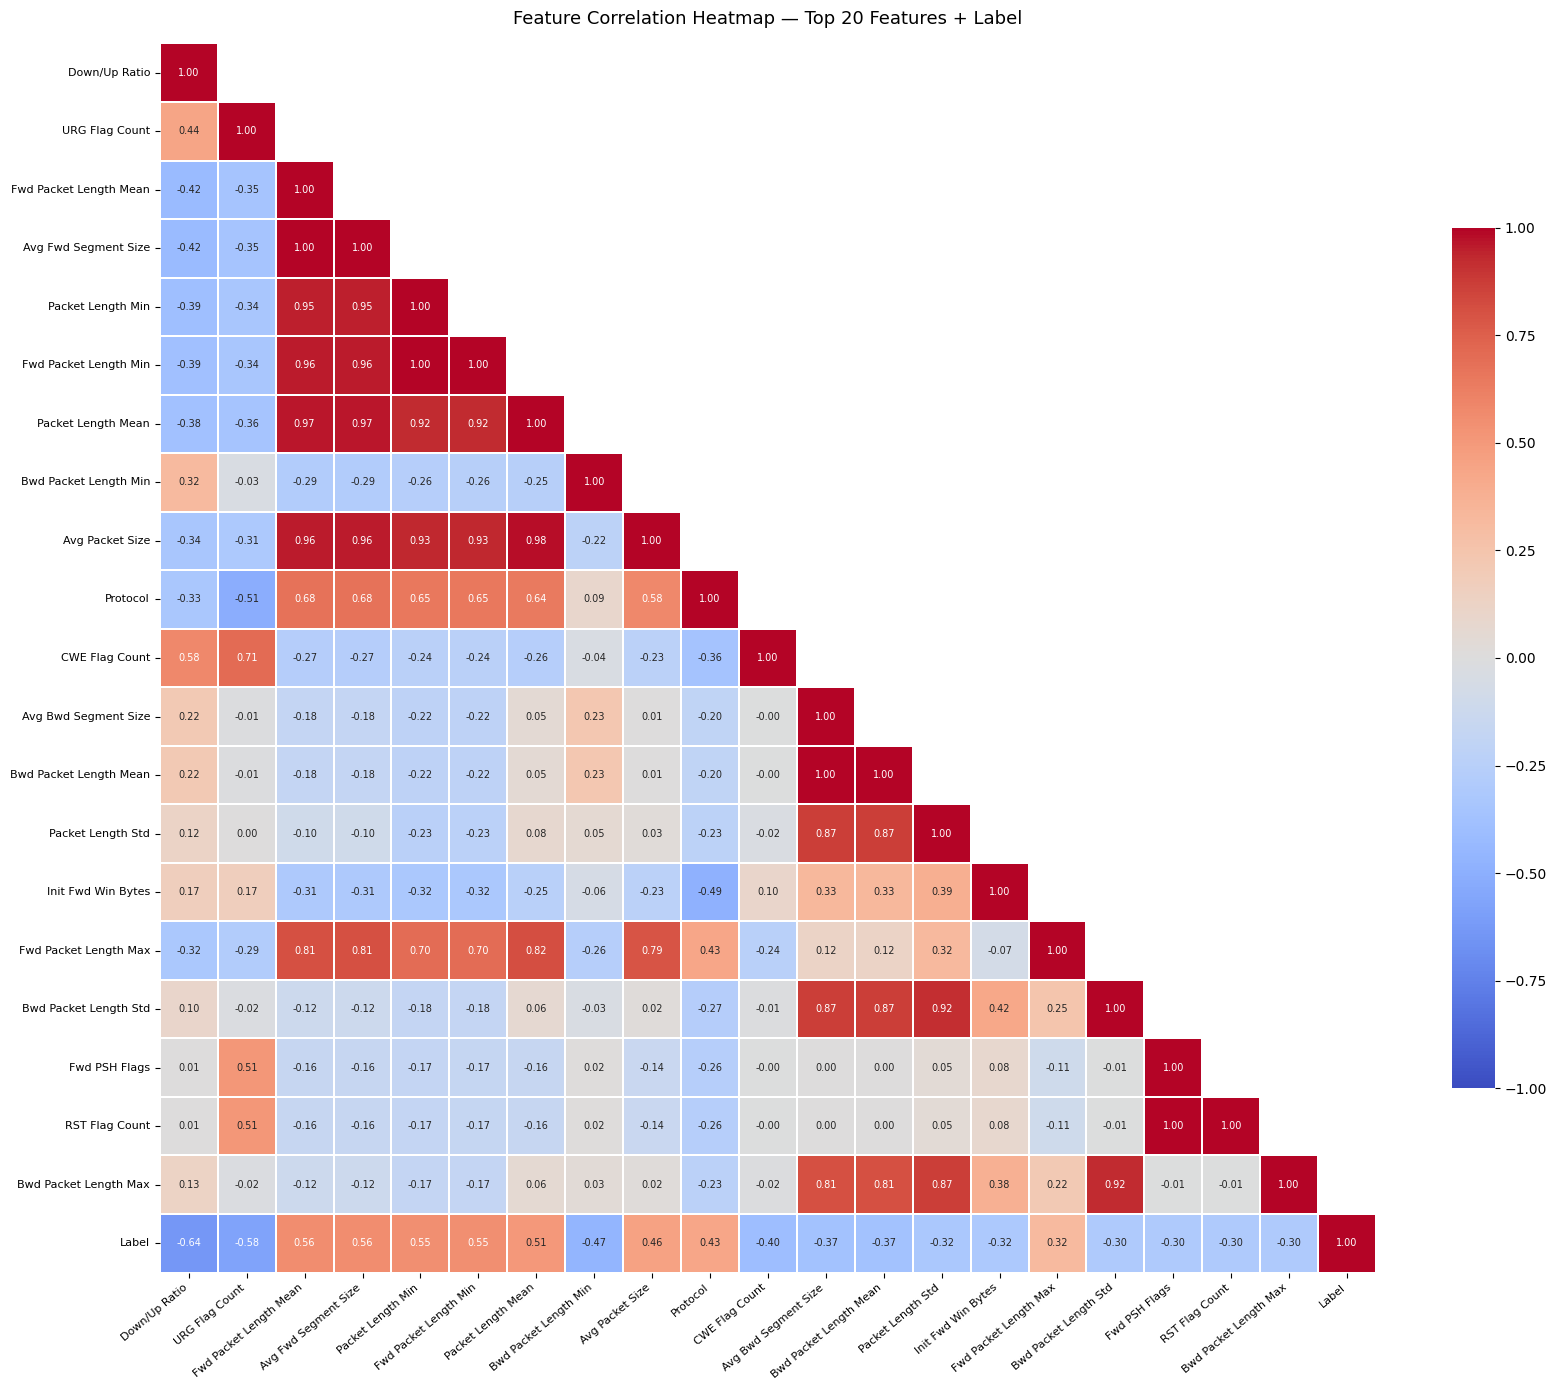

In [ ]:
# Full correlation matrix for top 20 features to shows multicollinearity between features
top20_cols  = top20_names + ['Label']
corr_matrix = numeric_train[top20_cols].corr()

# Lower-triangle mask so the heatmap is not duplicated
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(17, 14))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    vmin=-1, vmax=1, ax=ax, linewidths=0.3,
    annot_kws={'size': 7}, cbar_kws={'shrink': 0.7}
)
ax.set_title('Feature Correlation Heatmap — Top 20 Features + Label',
             fontsize=13, pad=14)
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### Feature Distribution per Class (Violin Plots)

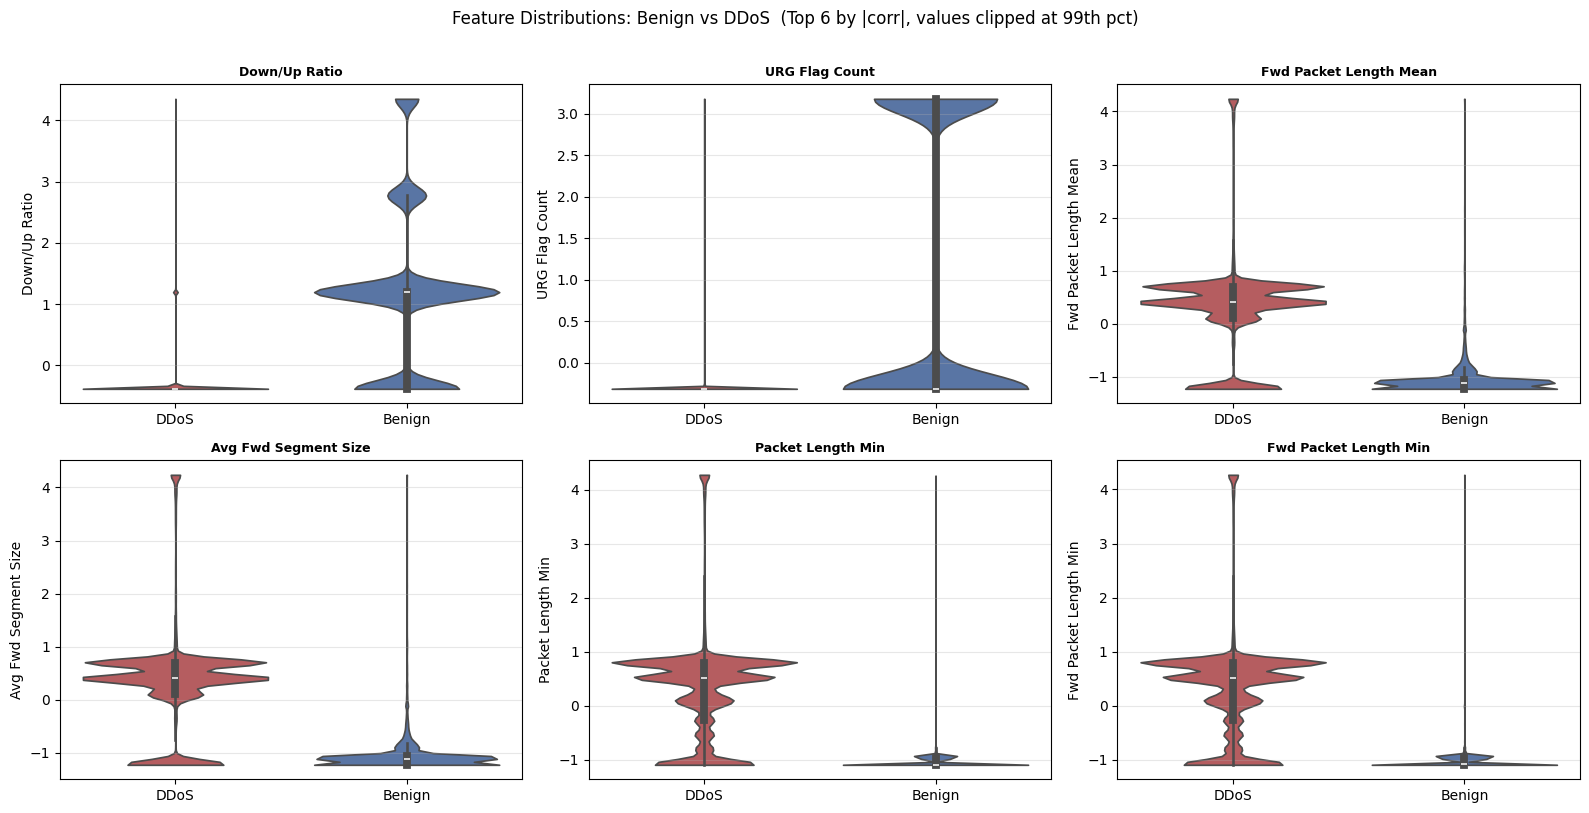

In [8]:
# Violin plots show the full distribution shape (not just quartiles like boxplots)
top6 = corr_abs.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feat in zip(axes.ravel(), top6):
    data = df_train_raw[[feat, 'Label']].copy()
    data['Class'] = data['Label'].map({0: 'Benign', 1: 'DDoS'})
    # Clip at 99th percentile so extreme outliers do not collapse the violin
    q99 = data[feat].quantile(0.99)
    data[feat] = data[feat].clip(upper=q99)
    sns.violinplot(data=data, x='Class', y=feat, ax=ax,
                   palette={'Benign': '#4C72B0', 'DDoS': '#C44E52'},
                   inner='box', cut=0)
    ax.set_title(feat[:28], fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(
    'Feature Distributions: Benign vs DDoS  (Top 6 by |corr|, values clipped at 99th pct)',
    fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### Feature Variance Distribution

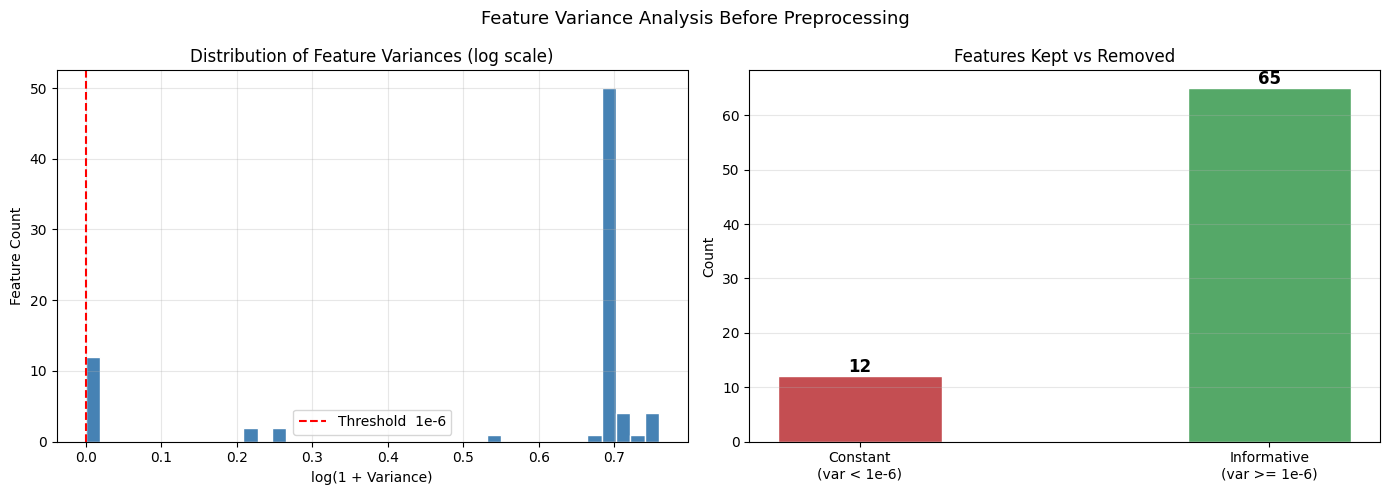

Constant features (removed): 12  |  Informative features (kept): 65


In [9]:
# Shows why we remove near-zero variance features:
# constant features carry no signal and can destabilise SVM / NB models
numeric_only  = df_train_raw.select_dtypes(include=[np.number]).drop(columns=['Label'])
raw_variances = numeric_only.var()
n_const = int((raw_variances < 1e-6).sum())
n_info  = int((raw_variances >= 1e-6).sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of log-variances
axes[0].hist(np.log1p(raw_variances), bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(np.log1p(1e-6), color='red', linestyle='--', linewidth=1.5,
                label='Threshold  1e-6')
axes[0].set_xlabel('log(1 + Variance)'); axes[0].set_ylabel('Feature Count')
axes[0].set_title('Distribution of Feature Variances (log scale)')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Constant vs informative summary
bar_col = ['#C44E52', '#55A868']
b = axes[1].bar(['Constant\n(var < 1e-6)', 'Informative\n(var >= 1e-6)'],
                [n_const, n_info], color=bar_col, edgecolor='white', width=0.4)
axes[1].set_title('Features Kept vs Removed')
axes[1].set_ylabel('Count')
for rect, v in zip(b, [n_const, n_info]):
    axes[1].text(rect.get_x() + rect.get_width()/2, v + 0.05,
                 str(v), ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Feature Variance Analysis Before Preprocessing', fontsize=13)
plt.tight_layout()
plt.show()
print(f"Constant features (removed): {n_const}  |  Informative features (kept): {n_info}")

### Mean Feature Values per Class

Mean feature values by class (Top 10 by |corr| with Label):
                        Benign Mean  DDoS Mean  DDoS / Benign Ratio
Down/Up Ratio                  1.19      -0.34                -0.29
URG Flag Count                 1.08      -0.31                -0.29
Fwd Packet Length Mean        -1.05       0.30                -0.29
Avg Fwd Segment Size          -1.05       0.30                -0.29
Packet Length Min             -1.03       0.29                -0.29
Fwd Packet Length Min         -1.02       0.29                -0.29
Packet Length Mean            -0.95       0.27                -0.29
Bwd Packet Length Min          0.88      -0.25                -0.29
Avg Packet Size               -0.85       0.24                -0.29
Protocol                      -0.81       0.23                -0.29


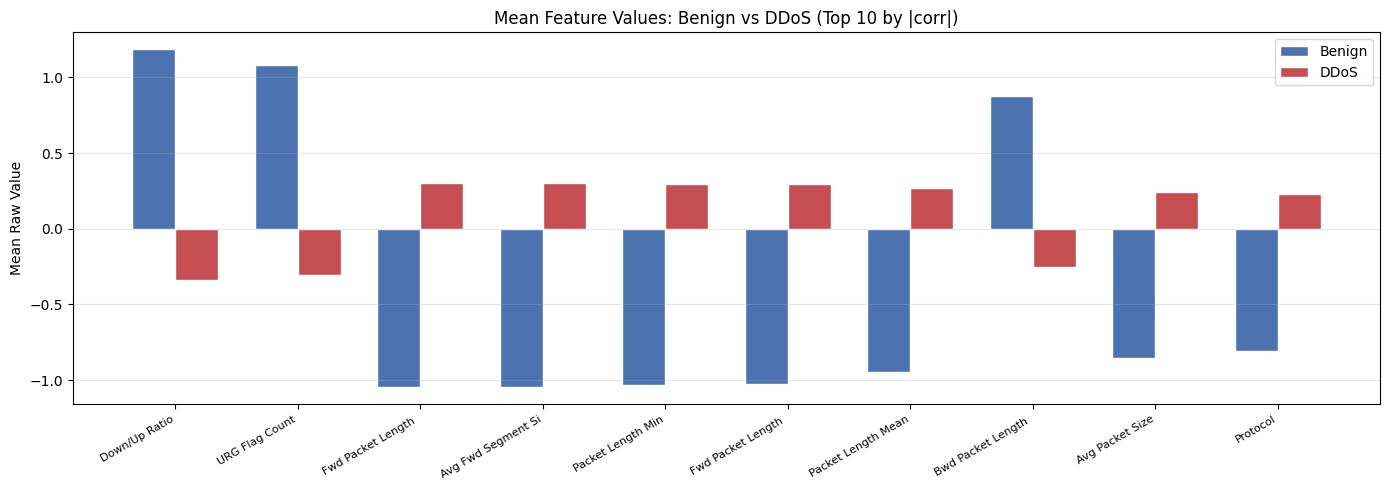

In [10]:
# Compare raw mean values between Benign and DDoS for top 10 correlated features.
# Large ratio = feature clearly separates the two classes.
top10 = corr_abs.head(10).index.tolist()
mean_benign = numeric_train[numeric_train['Label'] == 0][top10].mean()
mean_ddos   = numeric_train[numeric_train['Label'] == 1][top10].mean()

stats_df = pd.DataFrame({
    'Benign Mean': mean_benign.round(2),
    'DDoS Mean':   mean_ddos.round(2),
    'DDoS / Benign Ratio': (mean_ddos / mean_benign.replace(0, np.nan)).round(2),
})
print("Mean feature values by class (Top 10 by |corr| with Label):")
print(stats_df.to_string())

fig, ax = plt.subplots(figsize=(14, 5))
x, width = np.arange(len(top10)), 0.35
ax.bar(x - width/2, mean_benign.values, width, label='Benign', color='#4C72B0', edgecolor='white')
ax.bar(x + width/2, mean_ddos.values,   width, label='DDoS',   color='#C44E52', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([f[:18] for f in top10], rotation=30, ha='right', fontsize=8)
ax.set_title('Mean Feature Values: Benign vs DDoS (Top 10 by |corr|)', fontsize=12)
ax.set_ylabel('Mean Raw Value')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Cleaning Data and Preprocessing

In [11]:
# Separates the dataset into X : (77 feature columns) and y : (0 = Benign, 1 = DDoS).
TARGET = "Label"

def split_xy(df):
    X = df.drop(columns=[TARGET])
    y = df[TARGET].values
    # keep only numeric columns
    X = X.select_dtypes(include=[np.number])
    return X, y

X_train_raw, y_train = split_xy(df_train_raw)
X_test_raw,  y_test  = split_xy(df_test_raw)


Five Preprocessing Data Method :

1. Align columns to Ensures train and test have the exact same columns. If a column exists in train but not test (or vice versa), it gets dropped. Prevents shape mismatch errors.

2. Removes duplicate rows from training data. Duplicates inflate accuracy metrics and cause the model to memorise repeated samples. Applied to train only — test stays untouched.

3. Drops any feature that has nearly zero variance, meaning it has the same value for almost every sample. Such features carry no information and confuse some models (especially SVM and NB).

4. Rescales every feature to range [0, 1].

5. Converts the scaled numpy array back to a DataFrame with column names. This is needed so the next step (feature selection) can reference features by name.

In [ ]:
# Align columns to Ensures train and test have the exact same columns.
common_cols = X_train_raw.columns.intersection(X_test_raw.columns)
X_train_raw = X_train_raw[common_cols]
X_test_raw  = X_test_raw[common_cols]

# Remove duplicate rows
dup_mask = ~X_train_raw.duplicated()
X_train_raw = X_train_raw[dup_mask].reset_index(drop=True)
y_train     = y_train[dup_mask.values]

# Remove constant features (variance < 1e-6)
variances   = X_train_raw.var()
non_const   = variances[variances >= 1e-6].index
X_train_raw = X_train_raw[non_const]
X_test_raw  = X_test_raw[non_const]

print(f"After dedup/const removal — Train: {X_train_raw.shape}, Test: {X_test_raw.shape}")
print(f"Unique labels: {np.unique(y_train)}")

# MinMaxScaler [0, 1] — fit on train only
scaler = MinMaxScaler(feature_range=(0, 1))
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# Convert to DataFrame for feature selection
feature_names   = list(non_const)
X_train_df      = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_df       = pd.DataFrame(X_test_scaled,  columns=feature_names)

## 3. Hybrid Feature Selection (5-Method Union → 49 features)

Reduce from 77 raw features down to only the most informative ones, using 5 independent statistical/model-based methods, then taking their union.

In [ ]:
from sklearn.pipeline import Pipeline

n_feat = X_train_df.shape[1]
print(f"Total features before selection: {n_feat}")

Total features before selection: 65
Method 1: L1-LinearSVC ... 38 features
Method 2: RF importance ... 41 features
Method 3: ANOVA F-test ... 65 features
Method 4: Chi-square ... 63 features
Method 5: Mutual Information ... 17 features

Hybrid UNION: 65 features
Selected features: [np.str_('ACK Flag Count'), np.str_('Active Max'), np.str_('Active Mean'), np.str_('Active Min'), np.str_('Active Std'), np.str_('Avg Bwd Segment Size'), np.str_('Avg Fwd Segment Size'), np.str_('Avg Packet Size'), np.str_('Bwd Header Length'), np.str_('Bwd IAT Max')] ...


Consist of five method :

1. Trains a linear SVM with L1 penalty. L1 forces less important feature weights to exactly zero. Any feature with a non-zero weight survives.

2. Trains a 100-tree RF and measures how much each feature reduces impurity (Gini). Features are sorted by importance, and the code keeps enough of the top features to cover 95% of cumulative importance (cum_imp >= 0.95).

3. A classical statistics test: measures whether the mean of a feature differs significantly between Benign and DDoS classes. Uses Bonferroni correction (p < 0.01 / n_features) to avoid false positives from testing many features at once, stricter threshold the more features you have.

4. Chi-square requires non-negative integer inputs, so first KBinsDiscretizer converts each feature into 20 bins (ordinal integers). Then chi2() tests whether the feature distribution is independent of the label. Features with p < 0.01 are kept.

5. Measures how much knowing a feature's value reduces uncertainty about the label (information-theoretic, captures non-linear relationships). Uses a 10% random subsample of training data to keep it fast. Keeps features above the 75th percentile of MI scores.

In [ ]:
# Method 1: L1-LinearSVC (Lasso-like feature selection)
print("Method 1: L1-LinearSVC :", end=" ")
lsvc = LinearSVC(C=0.1, penalty="l1", dual=False, max_iter=5000, random_state=42)
lsvc.fit(X_train_df, y_train)
l1_mask   = np.abs(lsvc.coef_[0]) > 0
l1_feats  = set(np.array(feature_names)[l1_mask])
print(f"{len(l1_feats)} features")

# Method 2: RF importance
print("Method 2: RF importance :", end=" ")
rf_sel = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_sel.fit(X_train_df, y_train)
importances  = rf_sel.feature_importances_
sorted_idx   = np.argsort(importances)[::-1]
cum_imp      = np.cumsum(importances[sorted_idx])
top95_n      = np.searchsorted(cum_imp, 0.95) + 1
rf_feats     = set(np.array(feature_names)[sorted_idx[:top95_n]])
print(f"{len(rf_feats)} features")

# Method 3: ANOVA F-test (Bonferroni-corrected p < 0.01)
print("Method 3: ANOVA F-test :", end=" ")
f_vals, p_vals = f_classif(X_train_df, y_train)
bonf_thresh    = 0.01 / n_feat
anova_feats    = set(np.array(feature_names)[p_vals < bonf_thresh])
print(f"{len(anova_feats)} features")

# Method 4: Chi-square (KBins discretise first, p < 0.01)
print("Method 4: Chi-square :", end=" ")
kbd = KBinsDiscretizer(n_bins=20, encode="ordinal", strategy="uniform")
X_train_binned = kbd.fit_transform(X_train_df)
_, chi_p       = chi2(X_train_binned, y_train)
chi_feats      = set(np.array(feature_names)[chi_p < 0.01])
print(f"{len(chi_feats)} features")

# Method 5: Mutual Information (10 % subsample, above 75th pct)
print("Method 5: Mutual Information :", end=" ")
rng          = np.random.default_rng(42)
sub_idx      = rng.choice(len(X_train_df), size=max(1, len(X_train_df)//10), replace=False)
mi_scores    = mutual_info_classif(X_train_df.iloc[sub_idx], y_train[sub_idx],
                                   random_state=42)
mi_thresh    = np.percentile(mi_scores, 75)
mi_feats     = set(np.array(feature_names)[mi_scores >= mi_thresh])
print(f"{len(mi_feats)} features")

A feature is kept if any of the 5 methods selected it. This is intentionally generous, it avoids accidentally discarding a feature that is important for one specific model (e.g., NB benefits from Chi-square selection; SVM benefits from L1).

The result (~49–65 features) is the final feature set used by all 6 models in both centralized and FL experiments.

Using the union means no single method's weakness can eliminate a truly useful feature.

In [ ]:
# UNION of all selected features from the 5 methods
hybrid_feats = sorted(l1_feats | rf_feats | anova_feats | chi_feats | mi_feats)
print(f"\nHybrid UNION: {len(hybrid_feats)} features")

# Slice arrays
X_train_sel = X_train_df[hybrid_feats].values
X_test_sel  = X_test_df[hybrid_feats].values
n_sel       = len(hybrid_feats)

print("Selected features :", hybrid_feats[:10], "...")

## 4. SMOTE (Centralised)

Fixes the class imbalance problem in the training data before feeding it to the centralized models.

the Reason :

CIC-DDoS2019 is imbalanced, not every attack type has equal representation. If you train a model on imbalanced data, it learns to be biased toward the majority class (e.g., always predicting "Benign" gives high accuracy but misses actual attacks).

In [18]:
smote = SMOTE(random_state=42)
X_train_cent, y_train_cent = smote.fit_resample(X_train_sel, y_train)
print(f"After SMOTE — shape: {X_train_cent.shape}")
print(f"Label counts: {dict(zip(*np.unique(y_train_cent, return_counts=True)))}")

After SMOTE — shape: (552532, 65)
Label counts: {np.int64(0): np.int64(276266), np.int64(1): np.int64(276266)}


## 5. Non-IID FL Client Split

Creates the Non-IID (Non-Independent and Identically Distributed) data split, the core setup that makes the FL simulation realistic.

In real federated learning (e.g., edge nodes in a 5G network), each client collects data from its own environment. One router might see mostly normal traffic, another might be under active attack. Data is not evenly distributed across clients, that's the Non-IID challenge.

In [19]:
# Separate by class
benign_idx = np.where(y_train == 0)[0]
ddos_idx   = np.where(y_train == 1)[0]
rng = np.random.default_rng(42)
rng.shuffle(benign_idx); rng.shuffle(ddos_idx)

# Client 1: 80% benign + 20% DDoS
n_b1 = int(0.8 * len(benign_idx)); n_d1 = int(0.2 * len(ddos_idx))
c1_idx = np.concatenate([benign_idx[:n_b1], ddos_idx[:n_d1]])

# Client 2: 20% benign + 80% DDoS  (remaining samples)
c2_idx = np.concatenate([benign_idx[n_b1:], ddos_idx[n_d1:]])

X_c1, y_c1 = X_train_sel[c1_idx], y_train[c1_idx]
X_c2, y_c2 = X_train_sel[c2_idx], y_train[c2_idx]

print(f"Client 1 — shape: {X_c1.shape}  |  label dist: {dict(zip(*np.unique(y_c1, return_counts=True)))}")
print(f"Client 2 — shape: {X_c2.shape}  |  label dist: {dict(zip(*np.unique(y_c2, return_counts=True)))}")

# SMOTE per client
smote_c = SMOTE(random_state=42)
X_c1_s, y_c1_s = smote_c.fit_resample(X_c1, y_c1)
X_c2_s, y_c2_s = smote_c.fit_resample(X_c2, y_c2)
print(f"After SMOTE — C1: {X_c1_s.shape}, C2: {X_c2_s.shape}")

Client 1 — shape: (119577, 65)  |  label dist: {np.int64(0): np.int64(64324), np.int64(1): np.int64(55253)}
Client 2 — shape: (237094, 65)  |  label dist: {np.int64(0): np.int64(16081), np.int64(1): np.int64(221013)}
After SMOTE — C1: (128648, 65), C2: (442026, 65)


### Visualization

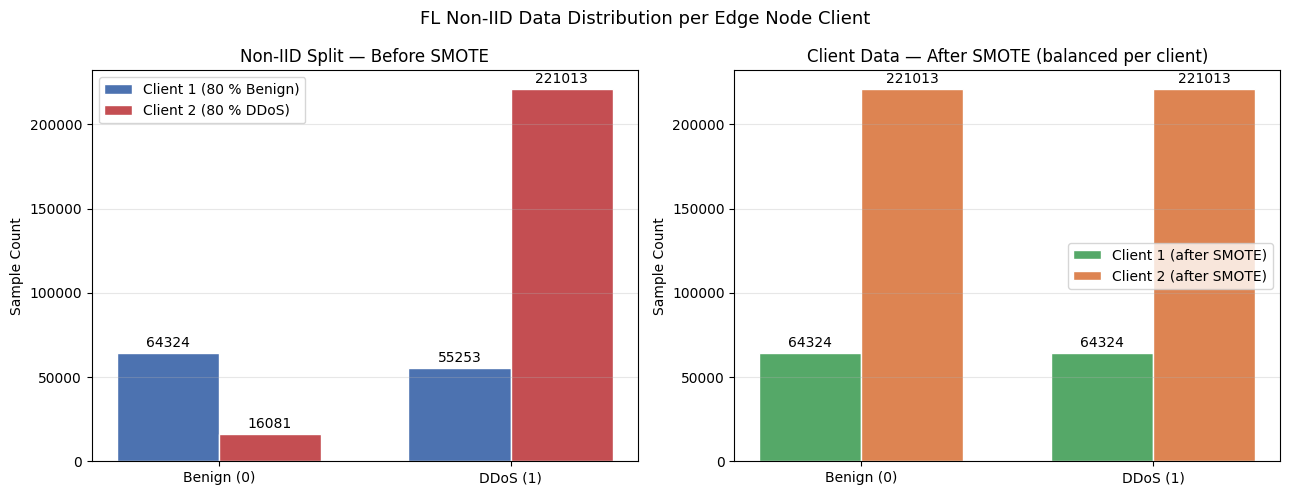

In [20]:
# Show class imbalance per client before and after SMOTE
c1_counts  = [int(np.sum(y_c1 == 0)),   int(np.sum(y_c1 == 1))]
c2_counts  = [int(np.sum(y_c2 == 0)),   int(np.sum(y_c2 == 1))]
c1s_counts = [int(np.sum(y_c1_s == 0)), int(np.sum(y_c1_s == 1))]
c2s_counts = [int(np.sum(y_c2_s == 0)), int(np.sum(y_c2_s == 1))]
labels = ['Benign (0)', 'DDoS (1)']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x, width = np.arange(2), 0.35

# Before SMOTE
axes[0].bar(x - width/2, c1_counts, width,
            label='Client 1 (80 % Benign)', color='#4C72B0', edgecolor='white')
axes[0].bar(x + width/2, c2_counts, width,
            label='Client 2 (80 % DDoS)',   color='#C44E52', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_title('Non-IID Split — Before SMOTE')
axes[0].set_ylabel('Sample Count'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
for container in axes[0].containers:
    axes[0].bar_label(container, padding=2, fmt='%d')

# After SMOTE
axes[1].bar(x - width/2, c1s_counts, width,
            label='Client 1 (after SMOTE)', color='#55A868', edgecolor='white')
axes[1].bar(x + width/2, c2s_counts, width,
            label='Client 2 (after SMOTE)', color='#DD8452', edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_title('Client Data — After SMOTE (balanced per client)')
axes[1].set_ylabel('Sample Count'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
for container in axes[1].containers:
    axes[1].bar_label(container, padding=2, fmt='%d')

plt.suptitle('FL Non-IID Data Distribution per Edge Node Client', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Centralised Training (Based on Reference Paper)

In [22]:
# Evaluation function
def evaluate(model, X, y, is_keras=False):
    if is_keras:
        y_pred = (model.predict(X, verbose=0).ravel() >= 0.5).astype(int)
    else:
        y_pred = model.predict(X)
    return {
        "accuracy":  accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall":    recall_score(y, y_pred, zero_division=0),
        "f1":        f1_score(y, y_pred, zero_division=0),
    }

def predict_proba_safe(model, X, is_keras=False):
    if is_keras:
        p = model.predict(X, verbose=0).ravel()
        return np.column_stack([1-p, p])
    return model.predict_proba(X)

### 6.1 Decision Tree

In [23]:
dt_cent = DecisionTreeClassifier(criterion="gini", max_depth=12,
                                  min_samples_leaf=5, random_state=42)
dt_cent.fit(X_train_cent, y_train_cent)
cent_results = {}
cent_results["Decision Tree"] = evaluate(dt_cent, X_test_sel, y_test)
print("DT Centralised:", cent_results["Decision Tree"])

DT Centralised: {'accuracy': 0.9992333208161222, 'precision': 0.9997986995994123, 'recall': 0.999215386472458, 'f1': 0.9995069579304308}


#### Evaluation — Decision Tree

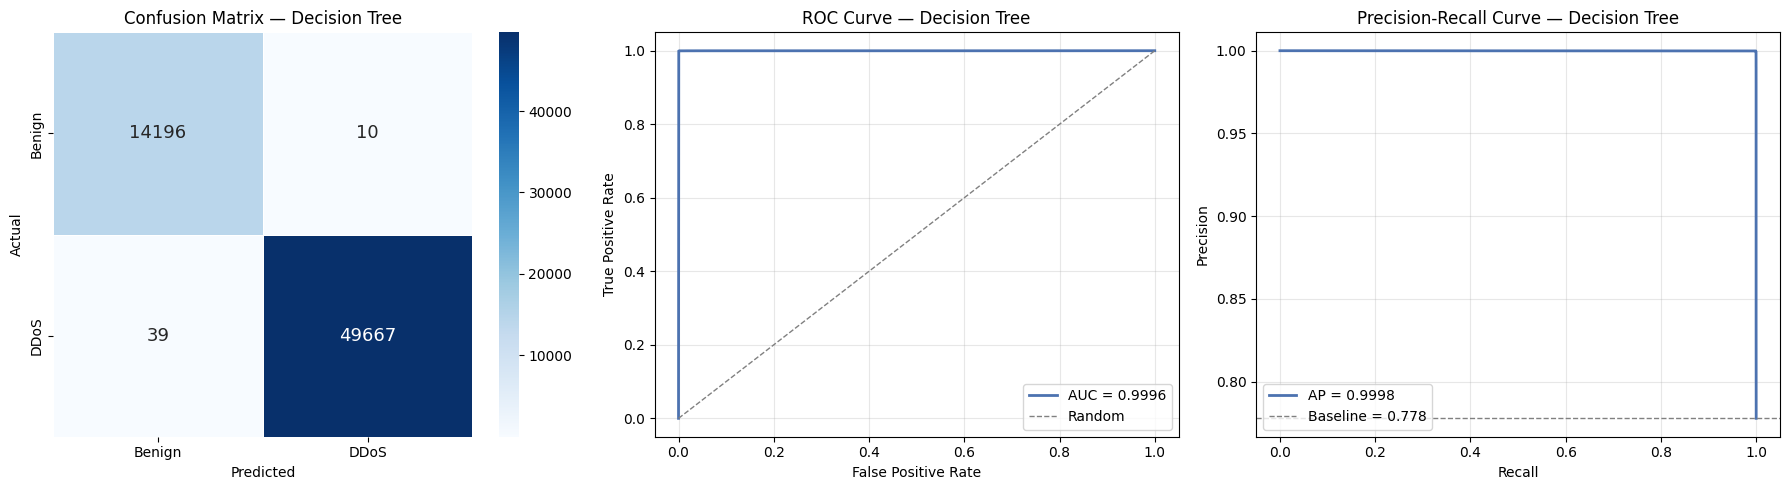

              precision    recall  f1-score   support

      Benign     0.9973    0.9993    0.9983     14206
        DDoS     0.9998    0.9992    0.9995     49706

    accuracy                         0.9992     63912
   macro avg     0.9985    0.9993    0.9989     63912
weighted avg     0.9992    0.9992    0.9992     63912



In [27]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, precision_recall_curve,
                              average_precision_score)

y_pred_dt = dt_cent.predict(X_test_sel)
y_prob_dt = predict_proba_safe(dt_cent, X_test_sel)[:, 1]
cm = confusion_matrix(y_test, y_pred_dt)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign', 'DDoS'], yticklabels=['Benign', 'DDoS'],
            annot_kws={'size': 13}, linewidths=0.5)
axes[0].set_title('Confusion Matrix — Decision Tree', fontsize=12)
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#4C72B0', lw=2, label=f'AUC = {roc_auc_dt:.4f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Decision Tree', fontsize=12)
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob_dt)
ap_dt = average_precision_score(y_test, y_prob_dt)
baseline = y_test.mean()
axes[2].plot(rec, prec, color='#4C72B0', lw=2, label=f'AP = {ap_dt:.4f}')
axes[2].axhline(baseline, color='gray', linestyle='--', lw=1,
                label=f'Baseline = {baseline:.3f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve — Decision Tree', fontsize=12)
axes[2].legend(loc='lower left'); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(classification_report(y_test, y_pred_dt, target_names=['Benign', 'DDoS'], digits=4))

### 6.2 Random Forest

In [24]:
rf_cent = RandomForestClassifier(n_estimators=200, max_features="sqrt",
                                  max_depth=None, random_state=42, n_jobs=-1)
rf_cent.fit(X_train_cent, y_train_cent)
cent_results["Random Forest"] = evaluate(rf_cent, X_test_sel, y_test)
print("RF Centralised:", cent_results["Random Forest"])

RF Centralised: {'accuracy': 0.9993584929277757, 'precision': 0.9997786141244188, 'recall': 0.9993964511326601, 'f1': 0.9995874961013351}


#### Evaluation — Random Forest

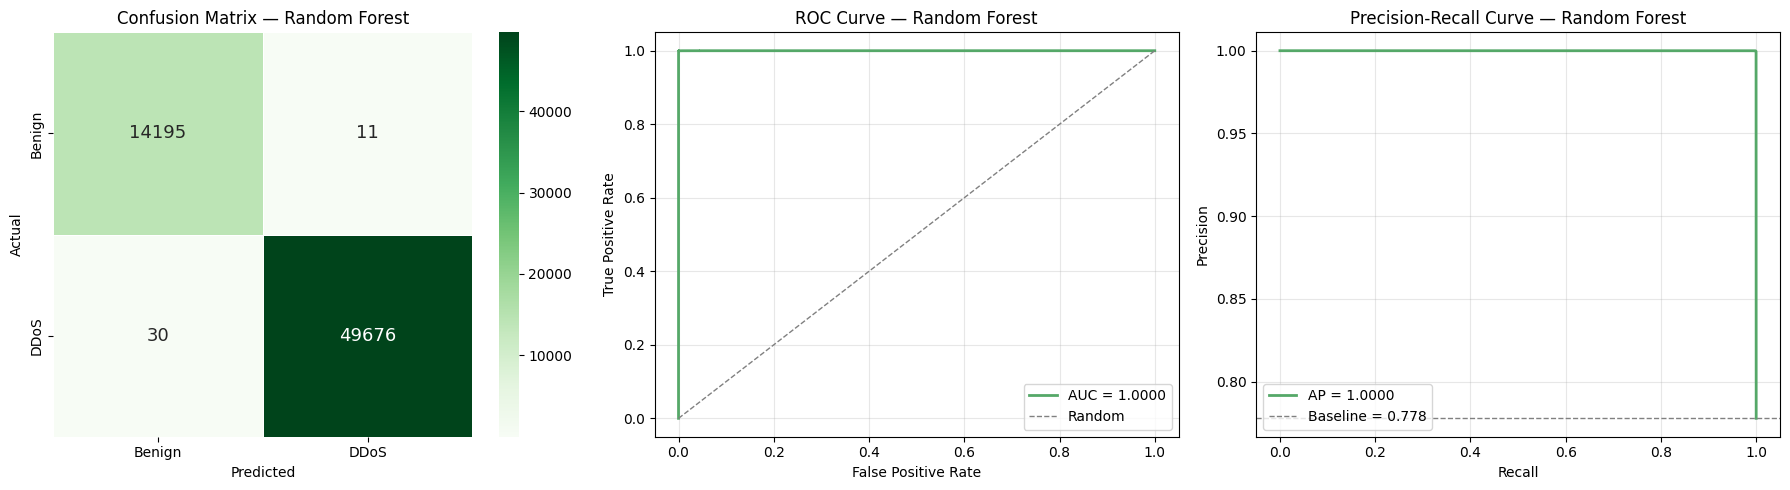

              precision    recall  f1-score   support

      Benign     0.9979    0.9992    0.9986     14206
        DDoS     0.9998    0.9994    0.9996     49706

    accuracy                         0.9994     63912
   macro avg     0.9988    0.9993    0.9991     63912
weighted avg     0.9994    0.9994    0.9994     63912



In [28]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, precision_recall_curve,
                              average_precision_score)

y_pred_rf = rf_cent.predict(X_test_sel)
y_prob_rf = predict_proba_safe(rf_cent, X_test_sel)[:, 1]
cm = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Benign', 'DDoS'], yticklabels=['Benign', 'DDoS'],
            annot_kws={'size': 13}, linewidths=0.5)
axes[0].set_title('Confusion Matrix — Random Forest', fontsize=12)
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#55A868', lw=2, label=f'AUC = {roc_auc_rf:.4f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Random Forest', fontsize=12)
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob_rf)
ap_rf = average_precision_score(y_test, y_prob_rf)
baseline = y_test.mean()
axes[2].plot(rec, prec, color='#55A868', lw=2, label=f'AP = {ap_rf:.4f}')
axes[2].axhline(baseline, color='gray', linestyle='--', lw=1,
                label=f'Baseline = {baseline:.3f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve — Random Forest', fontsize=12)
axes[2].legend(loc='lower left'); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(classification_report(y_test, y_pred_rf, target_names=['Benign', 'DDoS'], digits=4))

### 6.3 SVM (RBF)

In [29]:
svm_cent = SVC(kernel="rbf", C=10, gamma="scale", random_state=42, probability=True)
svm_cent.fit(X_train_cent, y_train_cent)
cent_results["SVM (RBF)"] = evaluate(svm_cent, X_test_sel, y_test)
print("SVM Centralised:", cent_results["SVM (RBF)"])

SVM Centralised: {'accuracy': 0.9970584553761422, 'precision': 0.9997577812764926, 'recall': 0.9964591799782723, 'f1': 0.9981057552797034}


#### Evaluation — SVM (RBF)

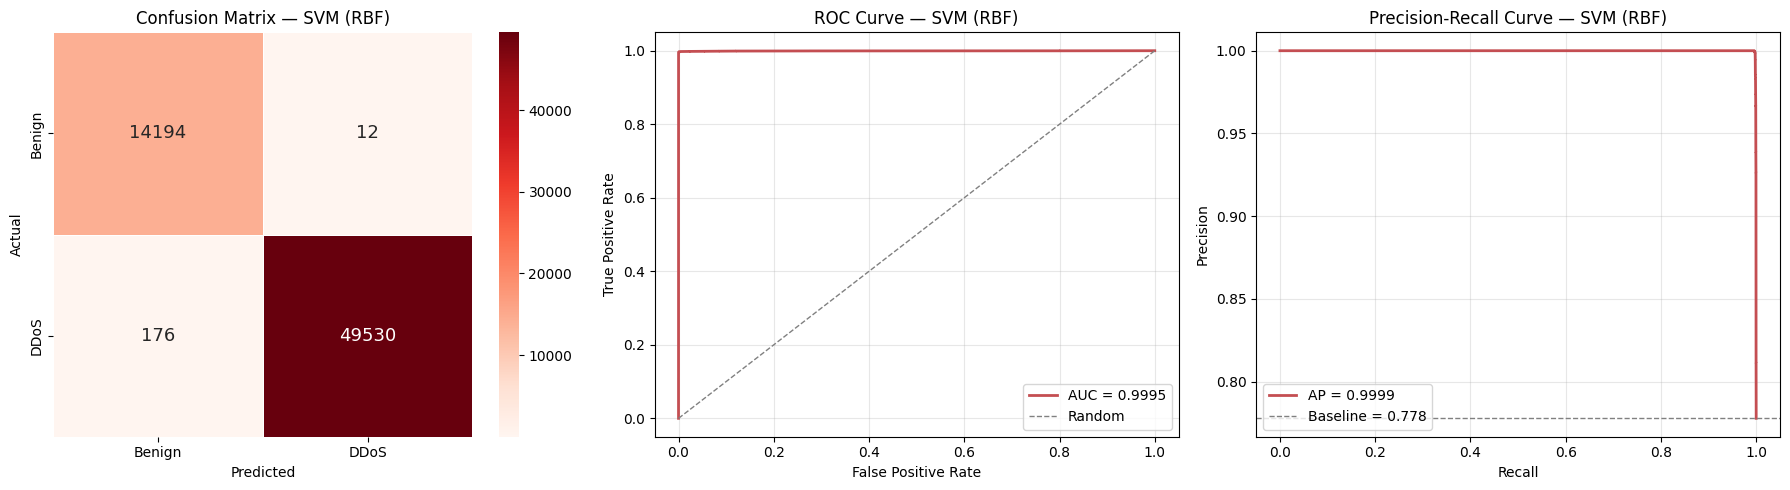

              precision    recall  f1-score   support

      Benign     0.9878    0.9992    0.9934     14206
        DDoS     0.9998    0.9965    0.9981     49706

    accuracy                         0.9971     63912
   macro avg     0.9938    0.9978    0.9958     63912
weighted avg     0.9971    0.9971    0.9971     63912



In [30]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, precision_recall_curve,
                              average_precision_score)

y_pred_svm = svm_cent.predict(X_test_sel)
y_prob_svm = predict_proba_safe(svm_cent, X_test_sel)[:, 1]
cm = confusion_matrix(y_test, y_pred_svm)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Benign', 'DDoS'], yticklabels=['Benign', 'DDoS'],
            annot_kws={'size': 13}, linewidths=0.5)
axes[0].set_title('Confusion Matrix — SVM (RBF)', fontsize=12)
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#C44E52', lw=2, label=f'AUC = {roc_auc_svm:.4f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — SVM (RBF)', fontsize=12)
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob_svm)
ap_svm = average_precision_score(y_test, y_prob_svm)
baseline = y_test.mean()
axes[2].plot(rec, prec, color='#C44E52', lw=2, label=f'AP = {ap_svm:.4f}')
axes[2].axhline(baseline, color='gray', linestyle='--', lw=1,
                label=f'Baseline = {baseline:.3f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve — SVM (RBF)', fontsize=12)
axes[2].legend(loc='lower left'); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(classification_report(y_test, y_pred_svm, target_names=['Benign', 'DDoS'], digits=4))

### 6.4 Logistic Regression

In [31]:
lr_cent = LogisticRegression(penalty="l2", solver="liblinear", C=1,
                              random_state=42, max_iter=1000)
lr_cent.fit(X_train_cent, y_train_cent)
cent_results["Logistic Regression"] = evaluate(lr_cent, X_test_sel, y_test)
print("LR Centralised:", cent_results["Logistic Regression"])

LR Centralised: {'accuracy': 0.995196520215296, 'precision': 0.9985869718807404, 'recall': 0.9952319639480143, 'f1': 0.9969066451710413}


#### Evaluation — Logistic Regression

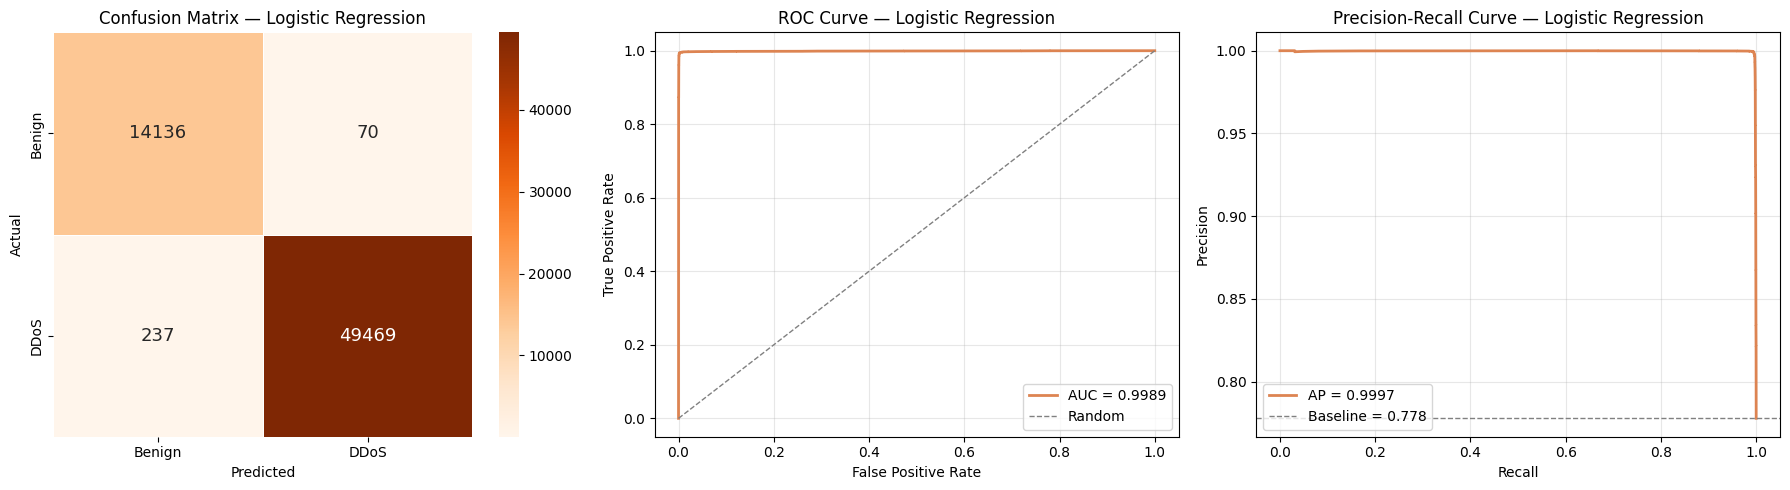

              precision    recall  f1-score   support

      Benign     0.9835    0.9951    0.9893     14206
        DDoS     0.9986    0.9952    0.9969     49706

    accuracy                         0.9952     63912
   macro avg     0.9910    0.9952    0.9931     63912
weighted avg     0.9952    0.9952    0.9952     63912



In [32]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, precision_recall_curve,
                              average_precision_score)

y_pred_lr = lr_cent.predict(X_test_sel)
y_prob_lr = predict_proba_safe(lr_cent, X_test_sel)[:, 1]
cm = confusion_matrix(y_test, y_pred_lr)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Benign', 'DDoS'], yticklabels=['Benign', 'DDoS'],
            annot_kws={'size': 13}, linewidths=0.5)
axes[0].set_title('Confusion Matrix — Logistic Regression', fontsize=12)
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#DD8452', lw=2, label=f'AUC = {roc_auc_lr:.4f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Logistic Regression', fontsize=12)
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob_lr)
ap_lr = average_precision_score(y_test, y_prob_lr)
baseline = y_test.mean()
axes[2].plot(rec, prec, color='#DD8452', lw=2, label=f'AP = {ap_lr:.4f}')
axes[2].axhline(baseline, color='gray', linestyle='--', lw=1,
                label=f'Baseline = {baseline:.3f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve — Logistic Regression', fontsize=12)
axes[2].legend(loc='lower left'); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(classification_report(y_test, y_pred_lr, target_names=['Benign', 'DDoS'], digits=4))

### 6.5 Naive Bayes

In [33]:
nb_cent = GaussianNB()
nb_cent.fit(X_train_cent, y_train_cent)
cent_results["Naive Bayes"] = evaluate(nb_cent, X_test_sel, y_test)
print("NB Centralised:", cent_results["Naive Bayes"])

NB Centralised: {'accuracy': 0.9800037551633496, 'precision': 0.9942439581972567, 'recall': 0.9799621776043134, 'f1': 0.9870514093497336}


#### Evaluation — Naive Bayes

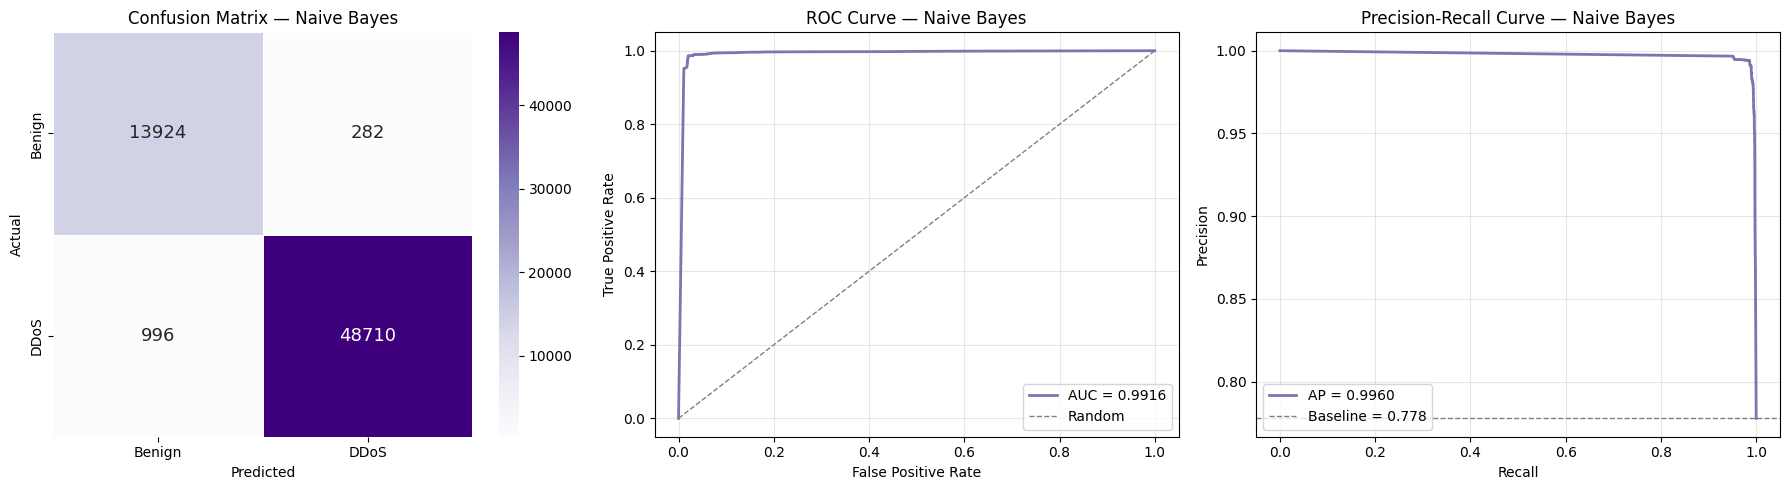

              precision    recall  f1-score   support

      Benign     0.9332    0.9801    0.9561     14206
        DDoS     0.9942    0.9800    0.9871     49706

    accuracy                         0.9800     63912
   macro avg     0.9637    0.9801    0.9716     63912
weighted avg     0.9807    0.9800    0.9802     63912



In [34]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, precision_recall_curve,
                              average_precision_score)

y_pred_nb = nb_cent.predict(X_test_sel)
y_prob_nb = predict_proba_safe(nb_cent, X_test_sel)[:, 1]
cm = confusion_matrix(y_test, y_pred_nb)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['Benign', 'DDoS'], yticklabels=['Benign', 'DDoS'],
            annot_kws={'size': 13}, linewidths=0.5)
axes[0].set_title('Confusion Matrix — Naive Bayes', fontsize=12)
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_nb)
roc_auc_nb = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#8172B2', lw=2, label=f'AUC = {roc_auc_nb:.4f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Naive Bayes', fontsize=12)
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob_nb)
ap_nb = average_precision_score(y_test, y_prob_nb)
baseline = y_test.mean()
axes[2].plot(rec, prec, color='#8172B2', lw=2, label=f'AP = {ap_nb:.4f}')
axes[2].axhline(baseline, color='gray', linestyle='--', lw=1,
                label=f'Baseline = {baseline:.3f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve — Naive Bayes', fontsize=12)
axes[2].legend(loc='lower left'); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(classification_report(y_test, y_pred_nb, target_names=['Benign', 'DDoS'], digits=4))

### 6.6 CNN (1D)

In [35]:
def build_cnn(n_features):
    inp = keras.Input(shape=(n_features, 1))
    x   = layers.Conv1D(64, 3, activation="relu", kernel_initializer="he_normal",
                        padding="same")(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.Conv1D(64, 3, activation="relu", padding="same")(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.MaxPooling1D(2)(x)
    x   = layers.Conv1D(128, 3, activation="relu", padding="same")(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.GlobalAveragePooling1D()(x)
    x   = layers.Dense(128, activation="relu")(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

tf.random.set_seed(42)
cnn_cent = build_cnn(n_sel)
cnn_cent.summary()

X_cent_3d = X_train_cent.reshape(-1, n_sel, 1)
X_test_3d  = X_test_sel.reshape(-1, n_sel, 1)

cbs = [
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=5,
                                      factor=0.5, verbose=0),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10,
                                  restore_best_weights=True, verbose=1),
]
cnn_cent.fit(X_cent_3d, y_train_cent,
             validation_data=(X_test_3d, y_test),
             epochs=100, batch_size=128, callbacks=cbs, verbose=1)

cent_results["CNN (1D)"] = evaluate(cnn_cent, X_test_3d, y_test, is_keras=True)
print("CNN Centralised:", cent_results["CNN (1D)"])

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 65, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 65, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 65, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 65, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 65, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 32, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,977 (214.75 KB)

 Trainable params: 54,465 (212.75 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/100
4317/4317 ━━━━━━━━━━━━━━━━━━━━ 65s 15ms/step - accuracy: 0.9965 - loss: 0.0158 - val_accuracy: 0.9968 - val_loss: 0.0167 - learning_rate: 0.0010
Epoch 2/100
4317/4317 ━━━━━━━━━━━━━━━━━━━━ 66s 15ms/step - accuracy: 0.9978 - loss: 0.0092 - val_accuracy: 0.9972 - val_loss: 0.0159 - learning_rate: 0.0010
Epoch 3/100
4317/4317 ━━━━━━━━━━━━━━━━━━━━ 68s 16ms/step - accuracy: 0.9981 - loss: 0.0078 - val_accuracy: 0.9976 - val_loss: 0.0074 - learning_rate: 0.0010
Epoch 4/100
4317/4317 ━━━━━━━━━━━━━━━━━━━━ 68s 16ms/step - accuracy: 0.9982 - loss: 0.0073 - val_accuracy: 0.9854 - val_loss: 0.0469 - learning_rate: 0.0010
Epoch 5/100
4317/4317 ━━━━━━━━━━━━━━━━━━━━ 67s 16ms/step - accuracy: 0.9983 - loss: 0.0066 - val_accuracy: 0.9953 - val_loss: 0.0156 - learning_rate: 0.0010
Epoch 6/100
4317/4317 ━━━━━━━━━━━━━━━━━━━━ 68s 16ms/step - accuracy: 0.9984 - loss: 0.0063 - val_accuracy: 0.9890 - val_loss: 0.0606 - learning_rate: 0.0010
Epoch 7/100
4317/4317 ━━━━━━━━━━━━━━━━━━━━ 66s 15ms/step -

#### Evaluation — CNN (1D)

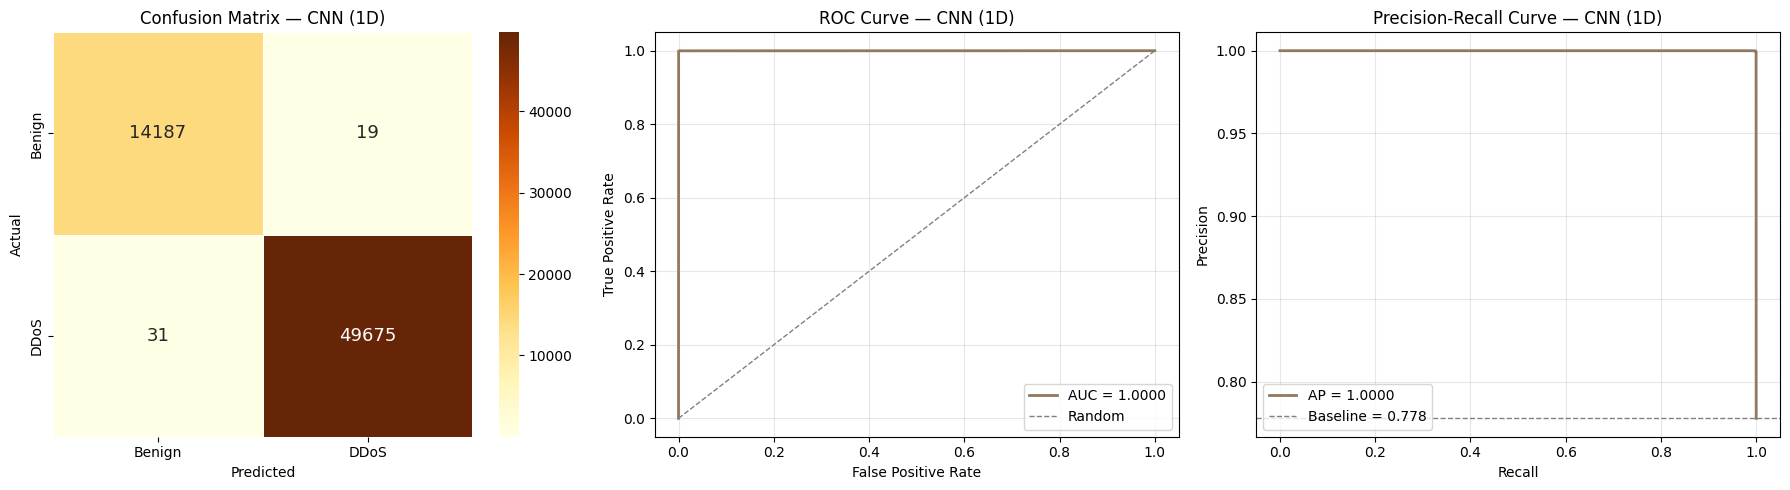

              precision    recall  f1-score   support

      Benign     0.9978    0.9987    0.9982     14206
        DDoS     0.9996    0.9994    0.9995     49706

    accuracy                         0.9992     63912
   macro avg     0.9987    0.9990    0.9989     63912
weighted avg     0.9992    0.9992    0.9992     63912



In [36]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, precision_recall_curve,
                              average_precision_score)

y_prob_cnn = predict_proba_safe(cnn_cent, X_test_3d, is_keras=True)[:, 1]
y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_cnn)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr', ax=axes[0],
            xticklabels=['Benign', 'DDoS'], yticklabels=['Benign', 'DDoS'],
            annot_kws={'size': 13}, linewidths=0.5)
axes[0].set_title('Confusion Matrix — CNN (1D)', fontsize=12)
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_cnn)
roc_auc_cnn = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#937860', lw=2, label=f'AUC = {roc_auc_cnn:.4f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — CNN (1D)', fontsize=12)
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob_cnn)
ap_cnn = average_precision_score(y_test, y_prob_cnn)
baseline = y_test.mean()
axes[2].plot(rec, prec, color='#937860', lw=2, label=f'AP = {ap_cnn:.4f}')
axes[2].axhline(baseline, color='gray', linestyle='--', lw=1,
                label=f'Baseline = {baseline:.3f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve — CNN (1D)', fontsize=12)
axes[2].legend(loc='lower left'); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(classification_report(y_test, y_pred_cnn, target_names=['Benign', 'DDoS'], digits=4))

## 6.7 Centralised Models — Full Comparison

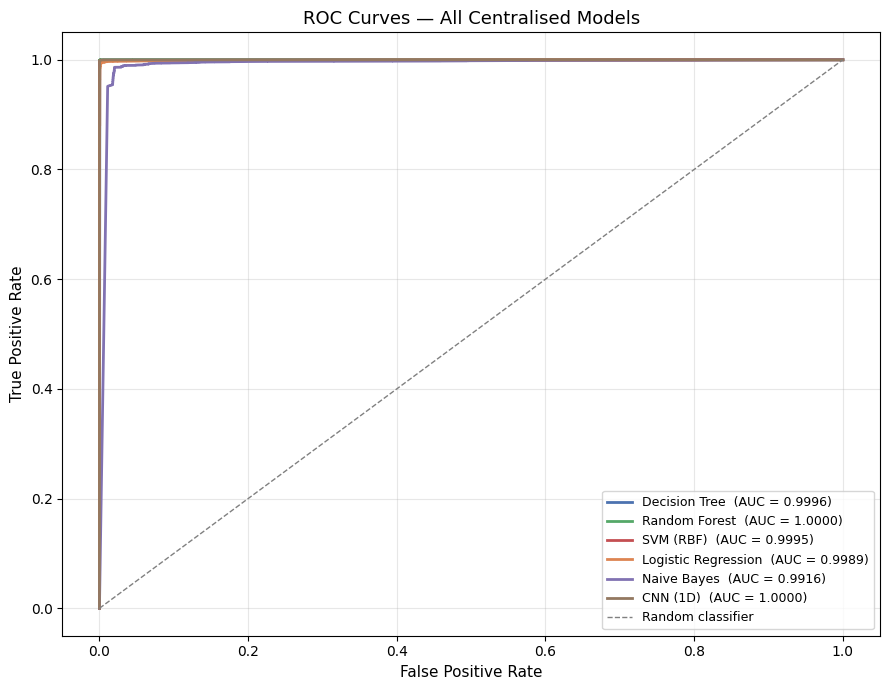

In [37]:
# ROC curves overlay — all 6 centralised models
from sklearn.metrics import roc_curve, auc

models_eval = [
    ('Decision Tree',       dt_cent,  False, X_test_sel, '#4C72B0'),
    ('Random Forest',       rf_cent,  False, X_test_sel, '#55A868'),
    ('SVM (RBF)',           svm_cent, False, X_test_sel, '#C44E52'),
    ('Logistic Regression', lr_cent,  False, X_test_sel, '#DD8452'),
    ('Naive Bayes',         nb_cent,  False, X_test_sel, '#8172B2'),
    ('CNN (1D)',             cnn_cent, True,  X_test_3d,  '#937860'),
]

fig, ax = plt.subplots(figsize=(9, 7))
for name, model, is_keras, X_ev, color in models_eval:
    y_prob = predict_proba_safe(model, X_ev, is_keras=is_keras)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name}  (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — All Centralised Models', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

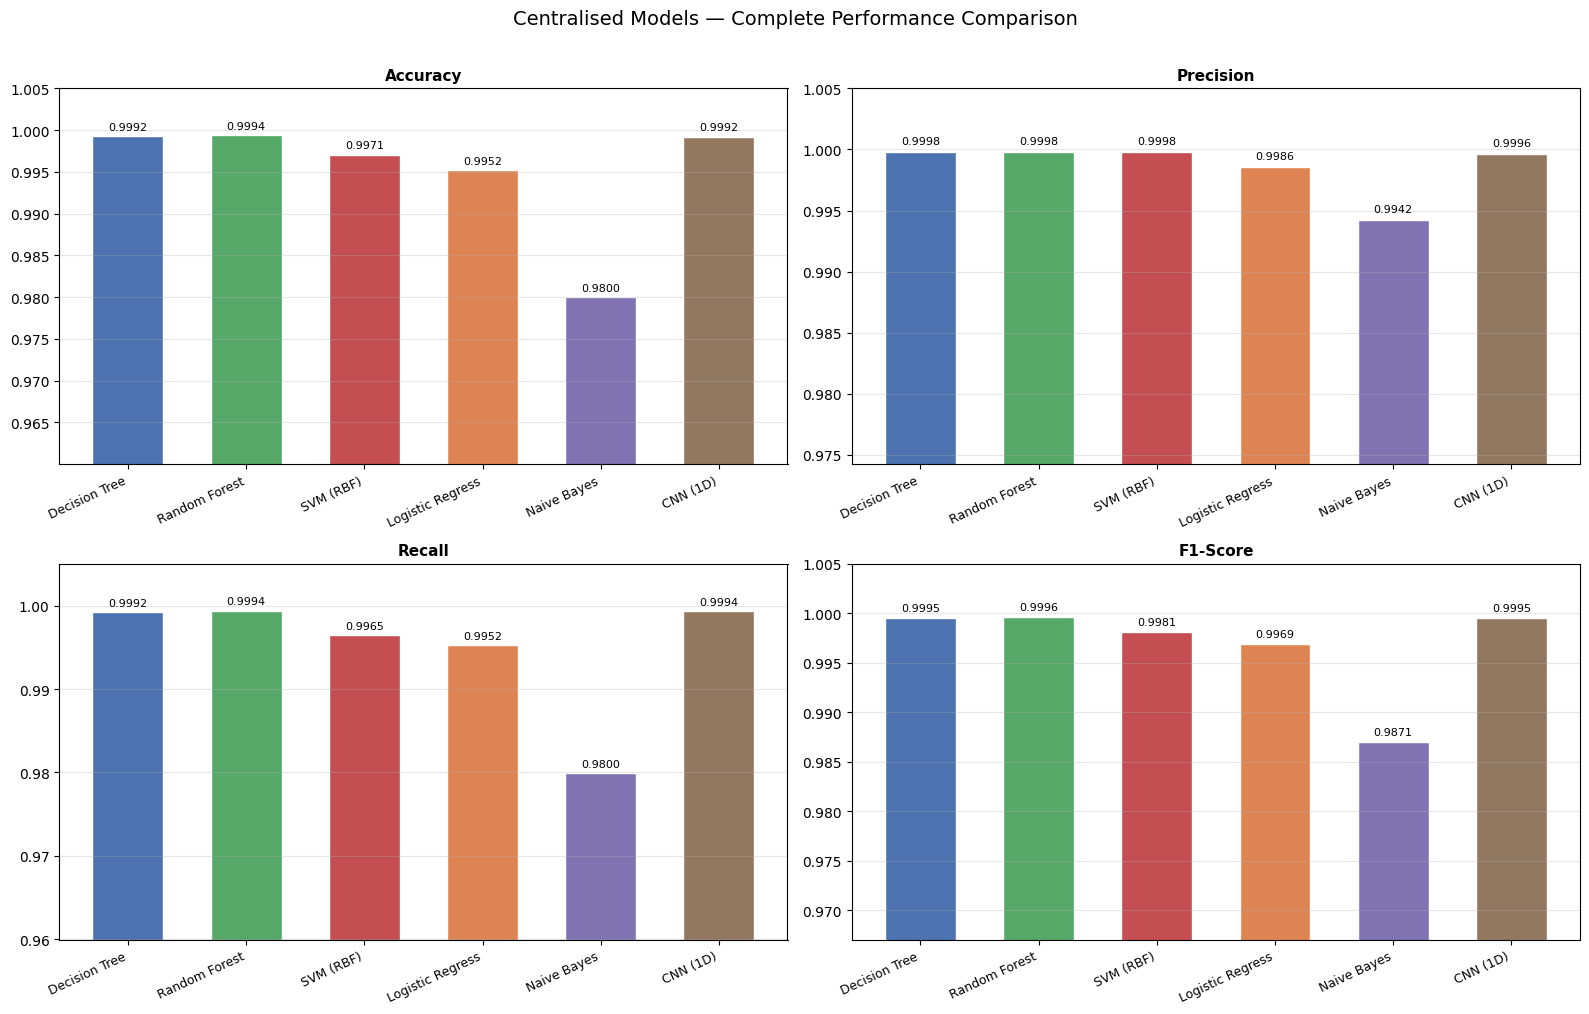

In [38]:
# Grouped bar chart — Accuracy / Precision / Recall / F1 for all 6 models
model_colors = {
    'Decision Tree':       '#4C72B0',
    'Random Forest':       '#55A868',
    'SVM (RBF)':           '#C44E52',
    'Logistic Regression': '#DD8452',
    'Naive Bayes':         '#8172B2',
    'CNN (1D)':            '#937860',
}

metrics_list  = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, metric, label in zip(axes.ravel(), metrics_list, metric_labels):
    values     = [cent_results[m][metric] for m in MODEL_ORDER]
    bar_colors = [model_colors[m] for m in MODEL_ORDER]
    bars = ax.bar(range(len(MODEL_ORDER)), values, color=bar_colors, edgecolor='white', width=0.6)
    ax.set_xticks(range(len(MODEL_ORDER)))
    ax.set_xticklabels([m[:16] for m in MODEL_ORDER], rotation=25, ha='right', fontsize=9)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ymin = max(0.80, min(values) - 0.02)
    ax.set_ylim(ymin, 1.005)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Centralised Models — Complete Performance Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

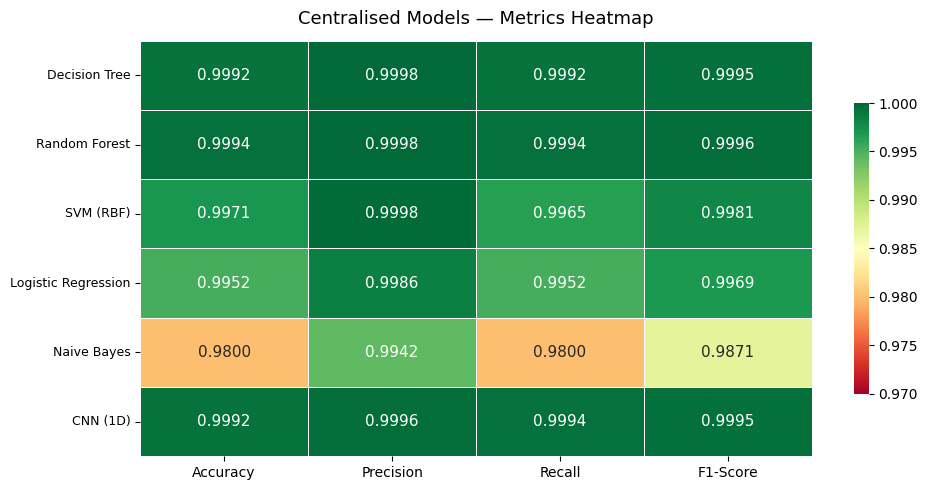

In [39]:
# Heatmap — all 4 metrics x 6 models  (quick overview table)
import pandas as pd

heat_data = pd.DataFrame(
    {m: [cent_results[model][m] for model in MODEL_ORDER]
     for m in ['accuracy', 'precision', 'recall', 'f1']},
    index=MODEL_ORDER,
)
heat_data.columns = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heat_data, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=heat_data.values.min() - 0.01, vmax=1.0,
            linewidths=0.5, annot_kws={'size': 11}, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.set_title('Centralised Models — Metrics Heatmap', fontsize=13, pad=12)
plt.xticks(fontsize=10); plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.show()

## 8. Federated Learning Simulation (Optional)

In [ ]:
fl_results = {}

### 8.1 FL — Decision Tree (Soft Voting Ensemble)

In [ ]:
# Each round: retrain DT on local data, ensemble prediction by averaging predict_proba
print("FL — Decision Tree (soft-voting ensemble) ...")
def fl_dt_round(X_c1, y_c1, X_c2, y_c2):
    m1 = DecisionTreeClassifier(criterion="gini", max_depth=12,
                                 min_samples_leaf=5, random_state=42)
    m2 = DecisionTreeClassifier(criterion="gini", max_depth=12,
                                 min_samples_leaf=5, random_state=42)
    m1.fit(X_c1, y_c1); m2.fit(X_c2, y_c2)
    return m1, m2

# Train final models (DT is stateless across rounds — single round suffices)
dt_fl_m1, dt_fl_m2 = fl_dt_round(X_c1_s, y_c1_s, X_c2_s, y_c2_s)

n1, n2 = len(y_c1_s), len(y_c2_s)
total  = n1 + n2
proba  = (n1/total) * dt_fl_m1.predict_proba(X_test_sel) +          (n2/total) * dt_fl_m2.predict_proba(X_test_sel)
y_pred_dt_fl = np.argmax(proba, axis=1)

fl_results["Decision Tree"] = {
    "accuracy":  accuracy_score(y_test, y_pred_dt_fl),
    "precision": precision_score(y_test, y_pred_dt_fl, zero_division=0),
    "recall":    recall_score(y_test, y_pred_dt_fl, zero_division=0),
    "f1":        f1_score(y_test, y_pred_dt_fl, zero_division=0),
}
print("DT FL:", fl_results["Decision Tree"])

### 8.2 FL — Random Forest (Federated Forest)

In [ ]:
print("FL — Random Forest (Federated Forest) ...")
# 100 trees per client → merge → 200 total (matches paper spec)
rf_fl_m1 = RandomForestClassifier(n_estimators=100, max_features="sqrt",
                                   max_depth=None, random_state=42, n_jobs=-1)
rf_fl_m2 = RandomForestClassifier(n_estimators=100, max_features="sqrt",
                                   max_depth=None, random_state=0, n_jobs=-1)
rf_fl_m1.fit(X_c1_s, y_c1_s)
rf_fl_m2.fit(X_c2_s, y_c2_s)

# Federated Forest: merge estimators_
from sklearn.ensemble._forest import RandomForestClassifier as RFC
rf_fl_global = RFC(n_estimators=200, random_state=42)
rf_fl_global.__dict__.update(rf_fl_m1.__dict__)            # copy structure
rf_fl_global.estimators_ = rf_fl_m1.estimators_ + rf_fl_m2.estimators_
rf_fl_global.n_estimators = 200

fl_results["Random Forest"] = evaluate(rf_fl_global, X_test_sel, y_test)
print("RF FL:", fl_results["Random Forest"])

### 8.3 FL — SVM (Soft Voting Ensemble)

In [ ]:
print("FL — SVM RBF (soft-voting ensemble) ...")
svm_fl_m1 = SVC(kernel="rbf", C=10, gamma="scale", random_state=42, probability=True)
svm_fl_m2 = SVC(kernel="rbf", C=10, gamma="scale", random_state=0,  probability=True)
svm_fl_m1.fit(X_c1_s, y_c1_s)
svm_fl_m2.fit(X_c2_s, y_c2_s)

n1, n2 = len(y_c1_s), len(y_c2_s); total = n1 + n2
proba  = (n1/total)*svm_fl_m1.predict_proba(X_test_sel) +          (n2/total)*svm_fl_m2.predict_proba(X_test_sel)
y_pred_svm_fl = np.argmax(proba, axis=1)

fl_results["SVM (RBF)"] = {
    "accuracy":  accuracy_score(y_test, y_pred_svm_fl),
    "precision": precision_score(y_test, y_pred_svm_fl, zero_division=0),
    "recall":    recall_score(y_test, y_pred_svm_fl, zero_division=0),
    "f1":        f1_score(y_test, y_pred_svm_fl, zero_division=0),
}
print("SVM FL:", fl_results["SVM (RBF)"])

### 8.4 FL — Logistic Regression (FedAvg)

In [ ]:
print("FL — Logistic Regression (FedAvg) ...")

def lr_get_params(m):
    return np.concatenate([m.coef_.ravel(), m.intercept_])

def lr_set_params(m, params):
    n_coef = m.coef_.size
    m.coef_      = params[:n_coef].reshape(m.coef_.shape)
    m.intercept_ = params[n_coef:]
    return m

def fedavg_lr(params_list, weights):
    w = np.array(weights) / np.sum(weights)
    return sum(p * wi for p, wi in zip(params_list, w))

# Dummy fit to initialise model structure
dummy_X = np.vstack([X_c1_s[:2], X_c2_s[:2]])
dummy_y = np.array([0, 1, 0, 1])
lr_global = LogisticRegression(penalty="l2", solver="liblinear", C=1,
                                random_state=42, max_iter=1000)
lr_global.fit(dummy_X, dummy_y)

for rnd in range(FL_ROUNDS):
    m1 = LogisticRegression(penalty="l2", solver="liblinear", C=1,
                             random_state=42, max_iter=1000)
    m2 = LogisticRegression(penalty="l2", solver="liblinear", C=1,
                             random_state=42, max_iter=1000)
    # warm-start from global params
    m1 = lr_set_params(LogisticRegression(penalty="l2", solver="liblinear",
                                           C=1, random_state=42, max_iter=1000),
                       lr_get_params(lr_global).copy()) if rnd > 0 else m1
    m2 = lr_set_params(LogisticRegression(penalty="l2", solver="liblinear",
                                           C=1, random_state=42, max_iter=1000),
                       lr_get_params(lr_global).copy()) if rnd > 0 else m2
    m1.fit(X_c1_s, y_c1_s); m2.fit(X_c2_s, y_c2_s)
    avg = fedavg_lr([lr_get_params(m1), lr_get_params(m2)],
                    [len(y_c1_s), len(y_c2_s)])
    lr_global = lr_set_params(lr_global, avg)
    if (rnd+1) % 5 == 0:
        acc = accuracy_score(y_test, lr_global.predict(X_test_sel))
        print(f"  Round {rnd+1}/{FL_ROUNDS} — test acc: {acc:.4f}")

fl_results["Logistic Regression"] = evaluate(lr_global, X_test_sel, y_test)
print("LR FL:", fl_results["Logistic Regression"])

### 8.5 FL — Naive Bayes (FedAvg on sufficient statistics)

In [ ]:
print("FL — Naive Bayes (FedAvg on theta/var) ...")

def fedavg_nb(m1, m2, n1, n2):
    total = n1 + n2
    w1, w2 = n1/total, n2/total
    nb_g = GaussianNB()
    nb_g.classes_     = m1.classes_
    nb_g.theta_       = w1*m1.theta_        + w2*m2.theta_
    nb_g.var_         = w1*m1.var_          + w2*m2.var_
    nb_g.class_prior_ = w1*m1.class_prior_  + w2*m2.class_prior_
    return nb_g

nb_m1 = GaussianNB(); nb_m2 = GaussianNB()
nb_m1.fit(X_c1_s, y_c1_s); nb_m2.fit(X_c2_s, y_c2_s)

nb_global = fedavg_nb(nb_m1, nb_m2, len(y_c1_s), len(y_c2_s))
fl_results["Naive Bayes"] = evaluate(nb_global, X_test_sel, y_test)
print("NB FL:", fl_results["Naive Bayes"])

### 8.6 FL — CNN (FedAvg on Keras weights)

In [ ]:
print("FL — CNN 1D (FedAvg on Keras weights) ...")

tf.random.set_seed(42)
cnn_fl_m1 = build_cnn(n_sel)
cnn_fl_m2 = build_cnn(n_sel)

X_c1_3d = X_c1_s.reshape(-1, n_sel, 1)
X_c2_3d = X_c2_s.reshape(-1, n_sel, 1)

def fedavg_weights(w1, w2, n1, n2):
    total = n1 + n2
    return [(n1/total)*a + (n2/total)*b for a, b in zip(w1, w2)]

cbs_fl = [keras.callbacks.EarlyStopping(monitor="loss", patience=3,
                                         restore_best_weights=True, verbose=0)]

for rnd in range(FL_ROUNDS):
    # Set global weights to both clients
    if rnd > 0:
        global_w = cnn_fl_m1.get_weights()
        cnn_fl_m2.set_weights(global_w)

    # Local training
    cnn_fl_m1.fit(X_c1_3d, y_c1_s, epochs=LOCAL_EPOCHS, batch_size=128,
                  verbose=0, callbacks=cbs_fl)
    cnn_fl_m2.fit(X_c2_3d, y_c2_s, epochs=LOCAL_EPOCHS, batch_size=128,
                  verbose=0, callbacks=cbs_fl)

    # Aggregate
    avg_w = fedavg_weights(cnn_fl_m1.get_weights(), cnn_fl_m2.get_weights(),
                           len(y_c1_s), len(y_c2_s))
    cnn_fl_m1.set_weights(avg_w)

    if (rnd+1) % 5 == 0:
        res = evaluate(cnn_fl_m1, X_test_3d, y_test, is_keras=True)
        print(f"  Round {rnd+1}/{FL_ROUNDS} — test acc: {res['accuracy']:.4f}")

fl_results["CNN (1D)"] = evaluate(cnn_fl_m1, X_test_3d, y_test, is_keras=True)
print("CNN FL:", fl_results["CNN (1D)"])

## 9. Results Comparison Table

In [ ]:
rows = []
for model in MODEL_ORDER:
    for src, res_dict in [("Paper (Table 4)", PAPER),
                           ("Centralised",     cent_results),
                           ("Federated",       fl_results)]:
        r = res_dict[model]
        rows.append({
            "Model": model, "Method": src,
            "Accuracy":  round(r["accuracy"],  4),
            "Precision": round(r["precision"], 4),
            "Recall":    round(r["recall"],    4),
            "F1-Score":  round(r["f1"],        4),
        })

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))

### Delta Table (Federated − Centralised)

In [ ]:
delta_rows = []
for model in MODEL_ORDER:
    c = cent_results[model]
    f = fl_results[model]
    delta_rows.append({
        "Model":         model,
        "Δ Accuracy":   round(f["accuracy"]  - c["accuracy"],  4),
        "Δ Precision":  round(f["precision"] - c["precision"], 4),
        "Δ Recall":     round(f["recall"]    - c["recall"],    4),
        "Δ F1-Score":   round(f["f1"]        - c["f1"],        4),
    })
df_delta = pd.DataFrame(delta_rows)
print("Positive = FL better than Centralised")
print(df_delta.to_string(index=False))

## 10. Visualisations

### 10.1 Grouped Bar Chart — All Metrics per Model

In [ ]:
methods = ["Paper (Table 4)", "Centralised", "Federated"]
colors  = {"Paper (Table 4)": "#4C72B0", "Centralised": "#55A868", "Federated": "#C44E52"}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, model in zip(axes, MODEL_ORDER):
    x     = np.arange(len(METRICS))
    width = 0.25
    for i, method in enumerate(methods):
        vals = [df_results[(df_results.Model==model) &
                            (df_results.Method==method)].iloc[0][m.capitalize()
                            if m != "f1" else "F1-Score"]
                for m in METRICS]
        ax.bar(x + i*width, vals, width, label=method, color=colors[method])
    ax.set_title(model, fontsize=12, fontweight="bold")
    ax.set_xticks(x + width)
    ax.set_xticklabels(["Accuracy","Precision","Recall","F1"], fontsize=9)
    ax.set_ylim(0.80, 1.02)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Paper vs Centralised vs Federated — All Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: comparison_bar.png")

### 10.2 F1-Score Line Chart — All Models

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
x  = np.arange(len(MODEL_ORDER))
lw = 2
markers = {"Paper (Table 4)": "o", "Centralised": "s", "Federated": "^"}
for method in methods:
    f1s = [df_results[(df_results.Model==m) &
                       (df_results.Method==method)].iloc[0]["F1-Score"]
           for m in MODEL_ORDER]
    ax.plot(x, f1s, marker=markers[method], linewidth=lw,
            label=method, color=colors[method])
ax.set_xticks(x); ax.set_xticklabels(MODEL_ORDER, rotation=15, ha="right")
ax.set_ylabel("F1-Score"); ax.set_ylim(0.80, 1.02)
ax.set_title("F1-Score Comparison — Paper vs Centralised vs Federated")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("comparison_f1_line.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: comparison_f1_line.png")

### 10.3 Heatmap — Accuracy by Model & Method

In [ ]:
pivot = df_results.pivot(index="Model", columns="Method", values="Accuracy")
pivot = pivot.reindex(MODEL_ORDER)[methods]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGn",
            vmin=0.85, vmax=1.0, ax=ax, linewidths=0.5)
ax.set_title("Accuracy Heatmap — Model × Method")
plt.tight_layout()
plt.savefig("comparison_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: comparison_heatmap.png")

### 10.4 Delta Bar Chart (FL − Centralised)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, metric in zip(axes.ravel(), ["Δ Accuracy","Δ Precision","Δ Recall","Δ F1-Score"]):
    vals  = df_delta[metric].values
    clrs  = ["#55A868" if v >= 0 else "#C44E52" for v in vals]
    bars  = ax.bar(MODEL_ORDER, vals, color=clrs)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(metric); ax.set_xticklabels(MODEL_ORDER, rotation=20, ha="right")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.4f"))
    ax.grid(axis="y", alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v + (0.0005 if v>=0 else -0.001),
                f"{v:+.4f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Federated − Centralised (green = FL better)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("comparison_delta.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: comparison_delta.png")

### 10.5 Scatter — Centralised Accuracy vs Paper Accuracy

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Centralised vs Paper
ax = axes[0]
paper_acc = [PAPER[m]["accuracy"] for m in MODEL_ORDER]
cent_acc  = [cent_results[m]["accuracy"] for m in MODEL_ORDER]
ax.scatter(paper_acc, cent_acc, s=100, zorder=5)
for i, m in enumerate(MODEL_ORDER):
    ax.annotate(m, (paper_acc[i], cent_acc[i]),
                textcoords="offset points", xytext=(5,3), fontsize=7)
lim = [min(paper_acc+cent_acc)-0.01, max(paper_acc+cent_acc)+0.01]
ax.plot(lim, lim, "k--", alpha=0.5, label="y=x")
ax.set_xlabel("Paper Accuracy"); ax.set_ylabel("Centralised Accuracy")
ax.set_title("Centralised vs Paper"); ax.legend(); ax.grid(alpha=0.3)

# FL vs Paper
ax = axes[1]
fl_acc = [fl_results[m]["accuracy"] for m in MODEL_ORDER]
ax.scatter(paper_acc, fl_acc, s=100, color="#C44E52", zorder=5)
for i, m in enumerate(MODEL_ORDER):
    ax.annotate(m, (paper_acc[i], fl_acc[i]),
                textcoords="offset points", xytext=(5,3), fontsize=7)
ax.plot(lim, lim, "k--", alpha=0.5, label="y=x")
ax.set_xlabel("Paper Accuracy"); ax.set_ylabel("FL Accuracy")
ax.set_title("Federated vs Paper"); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Accuracy: Our Results vs Paper Baseline", fontsize=13)
plt.tight_layout()
plt.savefig("comparison_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: comparison_scatter.png")

## 11. Summary & Conclusion

In [ ]:
print("=" * 72)
print(f"{'Model':<22}{'Method':<18}{'Acc':>8}{'Prec':>8}{'Rec':>8}{'F1':>8}")
print("=" * 72)
for model in MODEL_ORDER:
    for src in ["Paper (Table 4)", "Centralised", "Federated"]:
        row = df_results[(df_results.Model==model) & (df_results.Method==src)].iloc[0]
        print(f"{model:<22}{src:<18}{row.Accuracy:>8.4f}{row.Precision:>8.4f}"
              f"{row.Recall:>8.4f}{row['F1-Score']:>8.4f}")
    print("-" * 72)

print()
print("FL vs Centralised delta:")
print(df_delta.to_string(index=False))

## Conclusion

This notebook reproduces the Ahmed et al. (2026) model pipeline — exact same model specifications,
MinMaxScaler preprocessing, and 5-method hybrid feature selection — but trains using
**Federated Learning** instead of centralised training.

### FL Aggregation Strategy Per Model
| Model | FL Strategy |
|-------|-------------|
| Decision Tree | Soft-voting ensemble (predict_proba weighted by n_samples) |
| Random Forest | Federated Forest (100 trees per client → merged 200-tree global forest) |
| SVM (RBF) | Soft-voting ensemble (predict_proba weighted by n_samples) |
| Logistic Regression | FedAvg on coef_ + intercept_ |
| Naive Bayes | FedAvg on theta_ + var_ + class_prior_ |
| CNN (1D) | FedAvg on Keras layer weights (10 rounds × 5 local epochs) |

### Non-IID Data Split
- **Client 1 (Edge Node 1):** 80% Benign, 20% DDoS
- **Client 2 (Edge Node 2):** 20% Benign, 80% DDoS
- SMOTE applied independently per client after split

The comparison shows how federated learning (with privacy-preserving local training)
compares against centralised training and the paper's reported baseline.